# Experimentos Multi-Semilla — Validación Estadística
**Objetivo:** Reportar media ± desviación estándar de todas las métricas sobre 5 semillas  
**Semillas:** [42, 123, 456, 789, 2024]  
**Metodología:** Cada semilla genera un split estratificado distinto (80/10/10) por las 6 clases diagnósticas  
**Modelos:** Los 9 experimentos — binario Y multiclase — en un solo notebook  

> Los embeddings ya están guardados en Drive. Solo re-particionamos los índices en cada semilla  
> y entrenamos la cabeza clasificadora. No necesitamos volver a extraer embeddings.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, warnings
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SEEDS = [42, 123, 456, 789, 2024]

Dispositivo: cuda
GPU: Tesla T4


## 1. Cargar datos completos (metadata + embeddings)

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')
MULTI_PATH   = os.path.join(RESULTS_PATH, 'multisemilla')
os.makedirs(MULTI_PATH, exist_ok=True)

# Cargar metadata completa (sin split)
df_full = pd.read_csv(os.path.join(BASE_PATH, 'metadata_imputed.csv'))

# Cargar embeddings completos (train+val+test concatenados en el mismo orden que metadata)
# Necesitamos reconstruir el orden original
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))
df_splits = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Embeddings en el orden train/val/test original
clip_all = np.concatenate([
    np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy')),
    np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy')),
    np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))
], axis=0)
dino_all = np.concatenate([
    np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy')),
    np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy')),
    np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))
], axis=0)
convnext_all = np.concatenate([
    np.load(os.path.join(RESULTS_PATH, 'convnext_X_train.npy')),
    np.load(os.path.join(RESULTS_PATH, 'convnext_X_val.npy')),
    np.load(os.path.join(RESULTS_PATH, 'convnext_X_test.npy'))
], axis=0)

print(f'Total muestras: {len(df_splits)}')
print(f'CLIP: {clip_all.shape} | DINOv2: {dino_all.shape} | ConvNeXt: {convnext_all.shape}')

# Labels
CLASSES     = ['BCC', 'MEL', 'SCC', 'ACK', 'NEV', 'SEK']
class_to_idx = {c: i for i, c in enumerate(CLASSES)}

y_binary = df_splits['label'].values.astype(int)          # 0=benigno, 1=maligno
y_multi  = df_splits['diagnostic'].map(class_to_idx).values  # 0-5

print(f'\nDistribución binaria: {np.bincount(y_binary)}')
print(f'Distribución multiclase: {np.bincount(y_multi)}')

Total muestras: 2298
CLIP: (2298, 768) | DINOv2: (2298, 1024) | ConvNeXt: (2298, 1024)

Distribución binaria: [1209 1089]
Distribución multiclase: [845  52 192 730 244 235]


## 2. Preprocesar metadata clínica (todo el dataset)

In [4]:
META_COLS = ['smoke','drink','pesticide','gender','skin_cancer_history','cancer_history',
             'has_piped_water','has_sewage_system','age','fitspatrick','diameter_1','diameter_2',
             'region','background_father','background_mother','itch','grew','hurt','changed','bleed','elevation']
NUM_COLS  = ['age','fitspatrick','diameter_1','diameter_2']
CAT_COLS  = [c for c in META_COLS if c not in NUM_COLS]

# One-hot encoding sobre todo el dataset (para tener columnas consistentes)
meta_raw = df_splits[META_COLS].copy()
for col in meta_raw.select_dtypes(include='bool').columns:
    meta_raw[col] = meta_raw[col].astype(int)
string_cats = [c for c in CAT_COLS if meta_raw[c].dtype == object]
meta_encoded = pd.get_dummies(meta_raw, columns=string_cats)
meta_all = meta_encoded.values.astype(np.float32)

meta_dim = meta_all.shape[1]
print(f'Metadata procesada: {meta_all.shape}')

# Nota: el Min-Max scaling se aplica dentro de cada fold (fit en train, transform en val/test)
print(' Metadata lista (Min-Max se aplica por fold para evitar data leakage)')

Metadata procesada: (2298, 77)
 Metadata lista (Min-Max se aplica por fold para evitar data leakage)


## 3. Arquitecturas y loss functions

In [6]:
class LinearHead(nn.Module):
    """Cabeza clasificadora genérica — binaria o multiclase según n_classes."""
    def __init__(self, input_dim, n_classes=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.net(x)

class FusionModel(nn.Module):
    """Fusión intermedia propuesta — binaria o multiclase según n_classes."""
    def __init__(self, clip_dim=768, dino_dim=1024, meta_dim=None, proj_dim=256, n_classes=1, dropout=0.3):
        super().__init__()
        self.dino_proj = nn.Sequential(nn.Linear(dino_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.clip_proj = nn.Sequential(nn.Linear(clip_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.meta_mlp  = nn.Sequential(
            nn.Linear(meta_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, proj_dim), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim*3, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, xc, xd, xm):
        f = torch.cat([self.dino_proj(xd), self.clip_proj(xc), self.meta_mlp(xm)], dim=1)
        return self.classifier(f)

class FocalLossMulti(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        logp = F.log_softmax(logits, dim=1)
        ce   = F.nll_loss(logp, targets, weight=self.alpha, reduction='none')
        loss = (1 - torch.exp(-ce)) ** self.gamma * ce
        return loss.mean()

class FocalLossBinary(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p      = torch.sigmoid(logits)
        pt     = p * targets + (1-p) * (1-targets)
        alpha_t = self.alpha * targets + (1-self.alpha) * (1-targets)
        return (alpha_t * (1-pt)**self.gamma * bce).mean()

print('Arquitecturas y loss functions listas')

Arquitecturas y loss functions listas


## 4. Función principal de entrenamiento por fold

In [7]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

def scale_meta(meta_train, meta_val, meta_test):
    """Min-Max scaling fitteado en train, aplicado a val/test."""
    scaler = MinMaxScaler()
    # Solo escalar columnas numéricas originales
    num_idx = list(range(4))  # age, fitspatrick, diameter_1, diameter_2 son las primeras 4
    m_tr = meta_train.copy(); m_va = meta_val.copy(); m_te = meta_test.copy()
    m_tr[:, num_idx] = scaler.fit_transform(m_tr[:, num_idx])
    m_va[:, num_idx] = scaler.transform(m_va[:, num_idx])
    m_te[:, num_idx] = scaler.transform(m_te[:, num_idx])
    return m_tr, m_va, m_te

def train_fold(X_tr, y_tr, X_v, y_v, X_te, y_te, model, criterion, is_binary,
               lr=1e-3, epochs=50, patience=12):
    """Entrena un fold y devuelve métricas en test."""
    y_type_tr = torch.float32 if is_binary else torch.long
    y_type    = torch.float32 if is_binary else torch.long

    tl = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                                   torch.tensor(y_tr, dtype=y_type_tr)), batch_size=64, shuffle=True)
    vl = DataLoader(TensorDataset(torch.tensor(X_v, dtype=torch.float32),
                                   torch.tensor(y_v, dtype=y_type)), batch_size=64)
    tel= DataLoader(TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                                   torch.tensor(y_te, dtype=y_type)), batch_size=64)

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_score, best_state, pat = 0, None, 0

    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb).squeeze(1) if is_binary else model(xb)
            loss = criterion(out, yb); loss.backward(); opt.step()

        model.eval(); vprob, vpred, vtrue, vloss = [], [], [], 0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb).squeeze(1) if is_binary else model(xb)
                vloss += criterion(out, yb).item()
                if is_binary:
                    vprob.extend(torch.sigmoid(out).cpu().numpy())
                    vpred.extend((torch.sigmoid(out)>=0.5).long().cpu().numpy())
                else:
                    prob = torch.softmax(out, 1).cpu().numpy()
                    vprob.extend(prob); vpred.extend(out.argmax(1).cpu().numpy())
                vtrue.extend(yb.cpu().numpy())
        sch.step(vloss)

        score = roc_auc_score(vtrue, vprob) if is_binary else balanced_accuracy_score(vtrue, vpred)
        if score > best_score:
            best_score = score
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            pat = 0
        else:
            pat += 1
            if pat >= patience: break

    # Evaluación en test
    model.load_state_dict(best_state); model.eval()
    tprob, tpred, ttrue = [], [], []
    with torch.no_grad():
        for xb, yb in tel:
            out = model(xb.to(device)).squeeze(1) if is_binary else model(xb.to(device))
            if is_binary:
                tprob.extend(torch.sigmoid(out).cpu().numpy())
                tpred.extend((torch.sigmoid(out)>=0.5).long().cpu().numpy())
            else:
                prob = torch.softmax(out, 1).cpu().numpy()
                tprob.extend(prob); tpred.extend(out.argmax(1).cpu().numpy())
            ttrue.extend(yb.numpy())

    tprob, tpred, ttrue = np.array(tprob), np.array(tpred), np.array(ttrue)

    if is_binary:
        return {
            'auc':       roc_auc_score(ttrue, tprob),
            'accuracy':  accuracy_score(ttrue, tpred),
            'precision': precision_score(ttrue, tpred, zero_division=0),
            'recall':    recall_score(ttrue, tpred, zero_division=0),
            'f1':        f1_score(ttrue, tpred, zero_division=0)
        }
    else:
        return {
            'balanced_acc':    balanced_accuracy_score(ttrue, tpred),
            'accuracy':        accuracy_score(ttrue, tpred),
            'precision_macro': precision_score(ttrue, tpred, average='macro', zero_division=0),
            'recall_macro':    recall_score(ttrue, tpred, average='macro', zero_division=0),
            'f1_macro':        f1_score(ttrue, tpred, average='macro', zero_division=0),
            'auc_ovr':         roc_auc_score(ttrue, tprob, multi_class='ovr', average='macro')
        }

## 5. Función para agregar resultados (media ± std)

In [8]:
def agregar_resultados(lista_metricas):
    """Dado una lista de dicts de métricas (una por semilla), calcula media ± std."""
    keys = lista_metricas[0].keys()
    resultado = {}
    for k in keys:
        vals = np.array([m[k] for m in lista_metricas])
        resultado[k]           = round(vals.mean(), 4)
        resultado[k + '_std']  = round(vals.std(), 4)
        resultado[k + '_str']  = f'{vals.mean():.4f} ± {vals.std():.4f}'
    return resultado

def correr_experimento_multiseed(nombre, get_X_fn, is_binary, n_classes,
                                  use_focal=False, use_fusion=False):
    """
    Corre un experimento con 5 semillas y devuelve media ± std.
    get_X_fn(idx) → X (embeddings fusionados para los índices dados)
    """
    y = y_binary if is_binary else y_multi
    seed_results = []

    for seed in SEEDS:
        set_seed(seed)

        # Split estratificado con esta semilla
        sss_trainval = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
        train_val_idx, test_idx = next(sss_trainval.split(np.zeros(len(y)), y))
        y_tv = y[train_val_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.9, random_state=seed)
        train_idx_rel, val_idx_rel = next(sss_val.split(np.zeros(len(y_tv)), y_tv))
        train_idx = train_val_idx[train_idx_rel]
        val_idx   = train_val_idx[val_idx_rel]

        # Obtener features (se aplica Min-Max a metadata dentro de la función)
        X_tr, X_v, X_te = get_X_fn(train_idx, val_idx, test_idx)
        y_tr = y[train_idx]; y_v = y[val_idx]; y_te = y[test_idx]

        # Loss function
        if use_focal:
            if is_binary:
                criterion = FocalLossBinary(alpha=0.25, gamma=2.0)
            else:
                counts  = np.bincount(y_tr, minlength=6)
                weights = torch.tensor(len(y_tr)/(6*counts), dtype=torch.float32).to(device)
                criterion = FocalLossMulti(alpha=weights, gamma=2.0)
        else:
            criterion = nn.BCEWithLogitsLoss() if is_binary else nn.CrossEntropyLoss()

        # Modelo
        if use_fusion:
            # Para fusión, X_tr son las 3 modalidades por separado
            model = FusionModel(meta_dim=meta_dim, n_classes=n_classes)
            # Adaptar train_fold para fusion (X contiene clip, dino, meta separados)
            metrics = train_fold_fusion(X_tr, y_tr, X_v, y_v, X_te, y_te,
                                        model, criterion, is_binary)
        else:
            model = LinearHead(input_dim=X_tr.shape[1], n_classes=n_classes)
            metrics = train_fold(X_tr, y_tr, X_v, y_v, X_te, y_te,
                                 model, criterion, is_binary)

        seed_results.append(metrics)

    agg = agregar_resultados(seed_results)
    agg['modelo'] = nombre
    print(f'  {nombre:35s} → {list(agg.values())[0]:.4f} ± {list(agg.values())[1]:.4f}')
    return agg

def train_fold_fusion(Xsets_tr, y_tr, Xsets_v, y_v, Xsets_te, y_te,
                      model, criterion, is_binary, lr=1e-3, epochs=50, patience=12):
    """Versión de train_fold para la arquitectura de fusión (3 entradas separadas)."""
    y_type = torch.float32 if is_binary else torch.long
    c_tr, d_tr, m_tr = Xsets_tr
    c_v,  d_v,  m_v  = Xsets_v
    c_te, d_te, m_te = Xsets_te

    def mk_loader(c, d, m, y, shuffle=False):
        ds = TensorDataset(torch.tensor(c, dtype=torch.float32),
                           torch.tensor(d, dtype=torch.float32),
                           torch.tensor(m, dtype=torch.float32),
                           torch.tensor(y, dtype=y_type))
        return DataLoader(ds, batch_size=64, shuffle=shuffle)

    tl  = mk_loader(c_tr, d_tr, m_tr, y_tr, shuffle=True)
    vl  = mk_loader(c_v,  d_v,  m_v,  y_v)
    tel = mk_loader(c_te, d_te, m_te, y_te)

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_score, best_state, pat = 0, None, 0

    for ep in range(epochs):
        model.train()
        for xc, xd, xm, yb in tl:
            xc, xd, xm, yb = xc.to(device), xd.to(device), xm.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xc, xd, xm).squeeze(1) if is_binary else model(xc, xd, xm)
            loss = criterion(out, yb); loss.backward(); opt.step()

        model.eval(); vprob, vpred, vtrue, vloss = [], [], [], 0
        with torch.no_grad():
            for xc, xd, xm, yb in vl:
                xc, xd, xm, yb = xc.to(device), xd.to(device), xm.to(device), yb.to(device)
                out = model(xc, xd, xm).squeeze(1) if is_binary else model(xc, xd, xm)
                vloss += criterion(out, yb).item()
                if is_binary:
                    vprob.extend(torch.sigmoid(out).cpu().numpy())
                    vpred.extend((torch.sigmoid(out)>=0.5).long().cpu().numpy())
                else:
                    prob = torch.softmax(out,1).cpu().numpy()
                    vprob.extend(prob); vpred.extend(out.argmax(1).cpu().numpy())
                vtrue.extend(yb.cpu().numpy())
        sch.step(vloss)
        score = roc_auc_score(vtrue, vprob) if is_binary else balanced_accuracy_score(vtrue, vpred)
        if score > best_score:
            best_score = score; best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}; pat = 0
        else:
            pat += 1
            if pat >= patience: break

    model.load_state_dict(best_state); model.eval()
    tprob, tpred, ttrue = [], [], []
    with torch.no_grad():
        for xc, xd, xm, yb in tel:
            out = model(xc.to(device), xd.to(device), xm.to(device))
            out = out.squeeze(1) if is_binary else out
            if is_binary:
                tprob.extend(torch.sigmoid(out).cpu().numpy())
                tpred.extend((torch.sigmoid(out)>=0.5).long().cpu().numpy())
            else:
                prob = torch.softmax(out,1).cpu().numpy()
                tprob.extend(prob); tpred.extend(out.argmax(1).cpu().numpy())
            ttrue.extend(yb.numpy())

    tprob, tpred, ttrue = np.array(tprob), np.array(tpred), np.array(ttrue)
    if is_binary:
        return {'auc': roc_auc_score(ttrue, tprob), 'accuracy': accuracy_score(ttrue, tpred),
                'precision': precision_score(ttrue, tpred, zero_division=0),
                'recall': recall_score(ttrue, tpred, zero_division=0),
                'f1': f1_score(ttrue, tpred, zero_division=0)}
    else:
        return {'balanced_acc': balanced_accuracy_score(ttrue, tpred),
                'accuracy': accuracy_score(ttrue, tpred),
                'precision_macro': precision_score(ttrue, tpred, average='macro', zero_division=0),
                'recall_macro': recall_score(ttrue, tpred, average='macro', zero_division=0),
                'f1_macro': f1_score(ttrue, tpred, average='macro', zero_division=0),
                'auc_ovr': roc_auc_score(ttrue, tprob, multi_class='ovr', average='macro')}


## 6. Definir las funciones de features por experimento

In [9]:
# Cada función recibe índices de train/val/test y devuelve (X_tr, X_v, X_te)
# Para modelos sin metadata: devuelve directamente los embeddings
# Para modelos con metadata: aplica Min-Max en train y concatena

def get_meta_scaled(tr_idx, va_idx, te_idx):
    m_tr, m_va, m_te = scale_meta(meta_all[tr_idx], meta_all[va_idx], meta_all[te_idx])
    return m_tr, m_va, m_te

# --- Modelos solo imagen ---
def fx_clip(ti, vi, tei):   return clip_all[ti], clip_all[vi], clip_all[tei]
def fx_dino(ti, vi, tei):   return dino_all[ti], dino_all[vi], dino_all[tei]
def fx_conv(ti, vi, tei):   return convnext_all[ti], convnext_all[vi], convnext_all[tei]

# --- Visual + metadata ---
def fx_clip_meta(ti, vi, tei):
    m_tr, m_va, m_te = get_meta_scaled(ti, vi, tei)
    return (np.concatenate([clip_all[ti], m_tr], 1),
            np.concatenate([clip_all[vi], m_va], 1),
            np.concatenate([clip_all[tei],m_te], 1))

def fx_dino_meta(ti, vi, tei):
    m_tr, m_va, m_te = get_meta_scaled(ti, vi, tei)
    return (np.concatenate([dino_all[ti], m_tr], 1),
            np.concatenate([dino_all[vi], m_va], 1),
            np.concatenate([dino_all[tei],m_te], 1))

def fx_conv_meta(ti, vi, tei):
    m_tr, m_va, m_te = get_meta_scaled(ti, vi, tei)
    return (np.concatenate([convnext_all[ti], m_tr], 1),
            np.concatenate([convnext_all[vi], m_va], 1),
            np.concatenate([convnext_all[tei],m_te], 1))

# --- Fusión visual ---
def fx_clip_dino(ti, vi, tei):
    return (np.concatenate([clip_all[ti], dino_all[ti]], 1),
            np.concatenate([clip_all[vi], dino_all[vi]], 1),
            np.concatenate([clip_all[tei],dino_all[tei]], 1))

def fx_clip_dino_meta(ti, vi, tei):
    m_tr, m_va, m_te = get_meta_scaled(ti, vi, tei)
    return (np.concatenate([clip_all[ti], dino_all[ti], m_tr], 1),
            np.concatenate([clip_all[vi], dino_all[vi], m_va], 1),
            np.concatenate([clip_all[tei],dino_all[tei],m_te], 1))

# --- Fusión propuesta (devuelve 3 modalidades separadas) ---
def fx_fusion(ti, vi, tei):
    m_tr, m_va, m_te = get_meta_scaled(ti, vi, tei)
    return ((clip_all[ti], dino_all[ti], m_tr),
            (clip_all[vi], dino_all[vi], m_va),
            (clip_all[tei],dino_all[tei],m_te))


## 7. CORRER EXPERIMENTOS BINARIOS — 5 semillas
*(~15-20 min en T4)*

In [10]:
print('='*60)
print('  CLASIFICACIÓN BINARIA — 5 semillas (media ± std)')
print('  Métrica de selección: AUC de validación')
print('='*60)
print(f'  Semillas: {SEEDS}\n')

resultados_bin = []

print('--- Modelos solo imagen ---')
resultados_bin.append(correr_experimento_multiseed('CLIP solo',    fx_clip,    is_binary=True, n_classes=1))
resultados_bin.append(correr_experimento_multiseed('DINOv2 solo',  fx_dino,    is_binary=True, n_classes=1))
resultados_bin.append(correr_experimento_multiseed('ConvNeXt solo',fx_conv,    is_binary=True, n_classes=1))

print('\n--- Fusión visual ---')
resultados_bin.append(correr_experimento_multiseed('CLIP+DINOv2',  fx_clip_dino, is_binary=True, n_classes=1))

print('\n--- Visual + metadata ---')
resultados_bin.append(correr_experimento_multiseed('CLIP + metadata',    fx_clip_meta,  is_binary=True, n_classes=1))
resultados_bin.append(correr_experimento_multiseed('DINOv2 + metadata',  fx_dino_meta,  is_binary=True, n_classes=1))
resultados_bin.append(correr_experimento_multiseed('ConvNeXt + metadata',fx_conv_meta,  is_binary=True, n_classes=1))
resultados_bin.append(correr_experimento_multiseed('CLIP+DINOv2 + metadata', fx_clip_dino_meta, is_binary=True, n_classes=1))

print('\n--- Fusión propuesta (Focal Loss) ---')
resultados_bin.append(correr_experimento_multiseed('Fusión propuesta', fx_fusion,
                                                    is_binary=True, n_classes=1,
                                                    use_focal=True, use_fusion=True))


  CLASIFICACIÓN BINARIA — 5 semillas (media ± std)
  Métrica de selección: AUC de validación
  Semillas: [42, 123, 456, 789, 2024]

--- Modelos solo imagen ---
  CLIP solo                           → 0.9114 ± 0.0137
  DINOv2 solo                         → 0.8935 ± 0.0165
  ConvNeXt solo                       → 0.8703 ± 0.0337

--- Fusión visual ---
  CLIP+DINOv2                         → 0.9124 ± 0.0174

--- Visual + metadata ---
  CLIP + metadata                     → 0.9638 ± 0.0051
  DINOv2 + metadata                   → 0.9627 ± 0.0062
  ConvNeXt + metadata                 → 0.9537 ± 0.0049
  CLIP+DINOv2 + metadata              → 0.9662 ± 0.0071

--- Fusión propuesta (Focal Loss) ---
  Fusión propuesta                    → 0.9611 ± 0.0080


## 8. Tabla comparativa binaria con media ± std

In [11]:
df_bin = pd.DataFrame(resultados_bin)

# Tabla con formato legible (media ± std)
cols_str = ['modelo', 'auc_str', 'accuracy_str', 'precision_str', 'recall_str', 'f1_str']
df_bin_display = df_bin[cols_str].copy()
df_bin_display.columns = ['Modelo', 'AUC', 'Accuracy', 'Precision', 'Recall (Sensibilidad)', 'F1']
df_bin_display = df_bin_display.sort_values('AUC', ascending=False).reset_index(drop=True)

print('=== TABLA BINARIA — media ± std (5 semillas) ===\n')
print(df_bin_display.to_string(index=False))

df_bin.to_csv(os.path.join(MULTI_PATH, 'multisemilla_binario_completo.csv'), index=False)
df_bin_display.to_csv(os.path.join(MULTI_PATH, 'multisemilla_binario_display.csv'), index=False)
print('\n Guardado')

=== TABLA BINARIA — media ± std (5 semillas) ===

                Modelo             AUC        Accuracy       Precision Recall (Sensibilidad)              F1
CLIP+DINOv2 + metadata 0.9662 ± 0.0071 0.9148 ± 0.0085 0.9151 ± 0.0157       0.9046 ± 0.0222 0.9095 ± 0.0095
       CLIP + metadata 0.9638 ± 0.0051 0.9078 ± 0.0115 0.8889 ± 0.0294       0.9229 ± 0.0294 0.9047 ± 0.0108
     DINOv2 + metadata 0.9627 ± 0.0062 0.9087 ± 0.0148 0.9017 ± 0.0252       0.9083 ± 0.0485 0.9036 ± 0.0181
      Fusión propuesta 0.9611 ± 0.0080 0.8774 ± 0.0481 0.9163 ± 0.0183       0.8183 ± 0.1227 0.8581 ± 0.0718
   ConvNeXt + metadata 0.9537 ± 0.0049 0.8852 ± 0.0094 0.8743 ± 0.0194       0.8862 ± 0.0299 0.8796 ± 0.0110
           CLIP+DINOv2 0.9124 ± 0.0174 0.8217 ± 0.0184 0.8066 ± 0.0304       0.8257 ± 0.0713 0.8132 ± 0.0280
             CLIP solo 0.9114 ± 0.0137 0.8461 ± 0.0207 0.8307 ± 0.0436       0.8532 ± 0.0422 0.8402 ± 0.0203
           DINOv2 solo 0.8935 ± 0.0165 0.8183 ± 0.0187 0.8079 ± 0.0323       0

## 9. CORRER EXPERIMENTOS MULTICLASE — 5 semillas
*(~15-20 min en T4)*

In [12]:
print('='*60)
print('  CLASIFICACIÓN MULTICLASE (6 clases) — 5 semillas')
print('  Métrica de selección: Balanced Accuracy de validación')
print('='*60)
print(f'  Semillas: {SEEDS}')
print('  Loss: Focal Loss con pesos por clase (calculados en cada fold)\n')

resultados_multi = []

print('--- Modelos solo imagen ---')
resultados_multi.append(correr_experimento_multiseed('CLIP solo',    fx_clip, is_binary=False, n_classes=6, use_focal=True))
resultados_multi.append(correr_experimento_multiseed('DINOv2 solo',  fx_dino, is_binary=False, n_classes=6, use_focal=True))
resultados_multi.append(correr_experimento_multiseed('ConvNeXt solo',fx_conv, is_binary=False, n_classes=6, use_focal=True))

print('\n--- Fusión visual ---')
resultados_multi.append(correr_experimento_multiseed('CLIP+DINOv2', fx_clip_dino, is_binary=False, n_classes=6, use_focal=True))

print('\n--- Visual + metadata ---')
resultados_multi.append(correr_experimento_multiseed('CLIP + metadata',    fx_clip_meta,  is_binary=False, n_classes=6, use_focal=True))
resultados_multi.append(correr_experimento_multiseed('DINOv2 + metadata',  fx_dino_meta,  is_binary=False, n_classes=6, use_focal=True))
resultados_multi.append(correr_experimento_multiseed('ConvNeXt + metadata',fx_conv_meta,  is_binary=False, n_classes=6, use_focal=True))
resultados_multi.append(correr_experimento_multiseed('CLIP+DINOv2 + metadata', fx_clip_dino_meta, is_binary=False, n_classes=6, use_focal=True))

print('\n--- Fusión propuesta ---')
resultados_multi.append(correr_experimento_multiseed('Fusión propuesta', fx_fusion,
                                                      is_binary=False, n_classes=6,
                                                      use_focal=True, use_fusion=True))

print('\n Experimentos multiclase completados')

  CLASIFICACIÓN MULTICLASE (6 clases) — 5 semillas
  Métrica de selección: Balanced Accuracy de validación
  Semillas: [42, 123, 456, 789, 2024]
  Loss: Focal Loss con pesos por clase (calculados en cada fold)

--- Modelos solo imagen ---
  CLIP solo                           → 0.6084 ± 0.0362
  DINOv2 solo                         → 0.6066 ± 0.0444
  ConvNeXt solo                       → 0.5776 ± 0.0548

--- Fusión visual ---
  CLIP+DINOv2                         → 0.6406 ± 0.0318

--- Visual + metadata ---
  CLIP + metadata                     → 0.7126 ± 0.0306
  DINOv2 + metadata                   → 0.7291 ± 0.0247
  ConvNeXt + metadata                 → 0.7040 ± 0.0641
  CLIP+DINOv2 + metadata              → 0.7610 ± 0.0260

--- Fusión propuesta ---
  Fusión propuesta                    → 0.6741 ± 0.0527

 Experimentos multiclase completados


## 10. Tabla comparativa multiclase con media ± std

In [13]:
df_multi = pd.DataFrame(resultados_multi)

cols_str_m = ['modelo', 'balanced_acc_str', 'accuracy_str', 'precision_macro_str',
               'recall_macro_str', 'f1_macro_str', 'auc_ovr_str']
df_multi_display = df_multi[cols_str_m].copy()
df_multi_display.columns = ['Modelo', 'Balanced Acc', 'Accuracy',
                              'Precision (macro)', 'Sensibilidad (macro)', 'F1 (macro)', 'AUC (OvR)']
df_multi_display = df_multi_display.sort_values('Balanced Acc', ascending=False).reset_index(drop=True)

print('=== TABLA MULTICLASE — media ± std (5 semillas) ===\n')
print(df_multi_display.to_string(index=False))

df_multi.to_csv(os.path.join(MULTI_PATH, 'multisemilla_multiclase_completo.csv'), index=False)
df_multi_display.to_csv(os.path.join(MULTI_PATH, 'multisemilla_multiclase_display.csv'), index=False)
print('\n Guardado')

=== TABLA MULTICLASE — media ± std (5 semillas) ===

                Modelo    Balanced Acc        Accuracy Precision (macro) Sensibilidad (macro)      F1 (macro)       AUC (OvR)
CLIP+DINOv2 + metadata 0.7610 ± 0.0260 0.7174 ± 0.0208   0.7432 ± 0.0461      0.7610 ± 0.0260 0.7212 ± 0.0299 0.9535 ± 0.0077
     DINOv2 + metadata 0.7291 ± 0.0247 0.6461 ± 0.0376   0.6958 ± 0.0454      0.7291 ± 0.0247 0.6498 ± 0.0184 0.9441 ± 0.0065
       CLIP + metadata 0.7126 ± 0.0306 0.6617 ± 0.0382   0.6808 ± 0.0432      0.7126 ± 0.0306 0.6489 ± 0.0199 0.9463 ± 0.0069
   ConvNeXt + metadata 0.7040 ± 0.0641 0.6278 ± 0.0940   0.6566 ± 0.0689      0.7040 ± 0.0641 0.6207 ± 0.0782 0.9351 ± 0.0178
      Fusión propuesta 0.6741 ± 0.0527 0.6078 ± 0.1174   0.7215 ± 0.0489      0.6741 ± 0.0527 0.6218 ± 0.0736 0.9393 ± 0.0144
           CLIP+DINOv2 0.6406 ± 0.0318 0.5670 ± 0.0678   0.6430 ± 0.0166      0.6406 ± 0.0318 0.5842 ± 0.0512 0.9092 ± 0.0146
             CLIP solo 0.6084 ± 0.0362 0.4800 ± 0.0604   0.5945 ±

## 11. Resumen final — lo que va al póster y al artículo

In [14]:
print('\n' + '='*65)
print('  RESUMEN FINAL — MÉTRICAS CLAVE (para póster y artículo)')
print('='*65)

# Binario: propuesta vs mejor baseline
prop_bin  = next(r for r in resultados_bin  if r['modelo'] == 'Fusión propuesta')
best_bin  = max([r for r in resultados_bin if r['modelo'] != 'Fusión propuesta'], key=lambda x: x['auc'])
prop_multi = next(r for r in resultados_multi if r['modelo'] == 'Fusión propuesta')
best_multi = max([r for r in resultados_multi if r['modelo'] != 'Fusión propuesta'], key=lambda x: x['balanced_acc'])

print('\n BINARIO:')
print(f"  Fusión propuesta:  AUC {prop_bin['auc_str']}  |  Recall {prop_bin['recall_str']}")
print(f"  Mejor baseline:    AUC {best_bin['auc_str']}  |  Recall {best_bin['recall_str']}  ({best_bin['modelo']})")

print('\n MULTICLASE:')
print(f"  Fusión propuesta:  BACC {prop_multi['balanced_acc_str']}  |  AUC-OvR {prop_multi['auc_ovr_str']}")
print(f"  Mejor baseline:    BACC {best_multi['balanced_acc_str']}  |  AUC-OvR {best_multi['auc_ovr_str']}  ({best_multi['modelo']})")

print('\n Todos los resultados guardados en:', MULTI_PATH)


  RESUMEN FINAL — MÉTRICAS CLAVE (para póster y artículo)

 BINARIO:
  Fusión propuesta:  AUC 0.9611 ± 0.0080  |  Recall 0.8183 ± 0.1227
  Mejor baseline:    AUC 0.9662 ± 0.0071  |  Recall 0.9046 ± 0.0222  (CLIP+DINOv2 + metadata)

 MULTICLASE:
  Fusión propuesta:  BACC 0.6741 ± 0.0527  |  AUC-OvR 0.9393 ± 0.0144
  Mejor baseline:    BACC 0.7610 ± 0.0260  |  AUC-OvR 0.9535 ± 0.0077  (CLIP+DINOv2 + metadata)

 Todos los resultados guardados en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/multisemilla


## 12. Setup de visualizacion

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FIG_PATH = os.path.join(MULTI_PATH, 'figuras')
os.makedirs(FIG_PATH, exist_ok=True)

PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D',
           '#3B1F2B','#44BBA4','#E94F37','#393E41','#B5B5B5']
MODELOS_ORDER = [
    'CLIP solo','DINOv2 solo','ConvNeXt solo','CLIP+DINOv2',
    'CLIP + metadata','DINOv2 + metadata','ConvNeXt + metadata',
    'CLIP+DINOv2 + metadata','Fusion propuesta'
]

plt.rcParams.update({'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'figure.dpi':150})
print('Setup listo')

Setup listo


## 13. Figura 1 — Metricas binarias (barras media +- std)

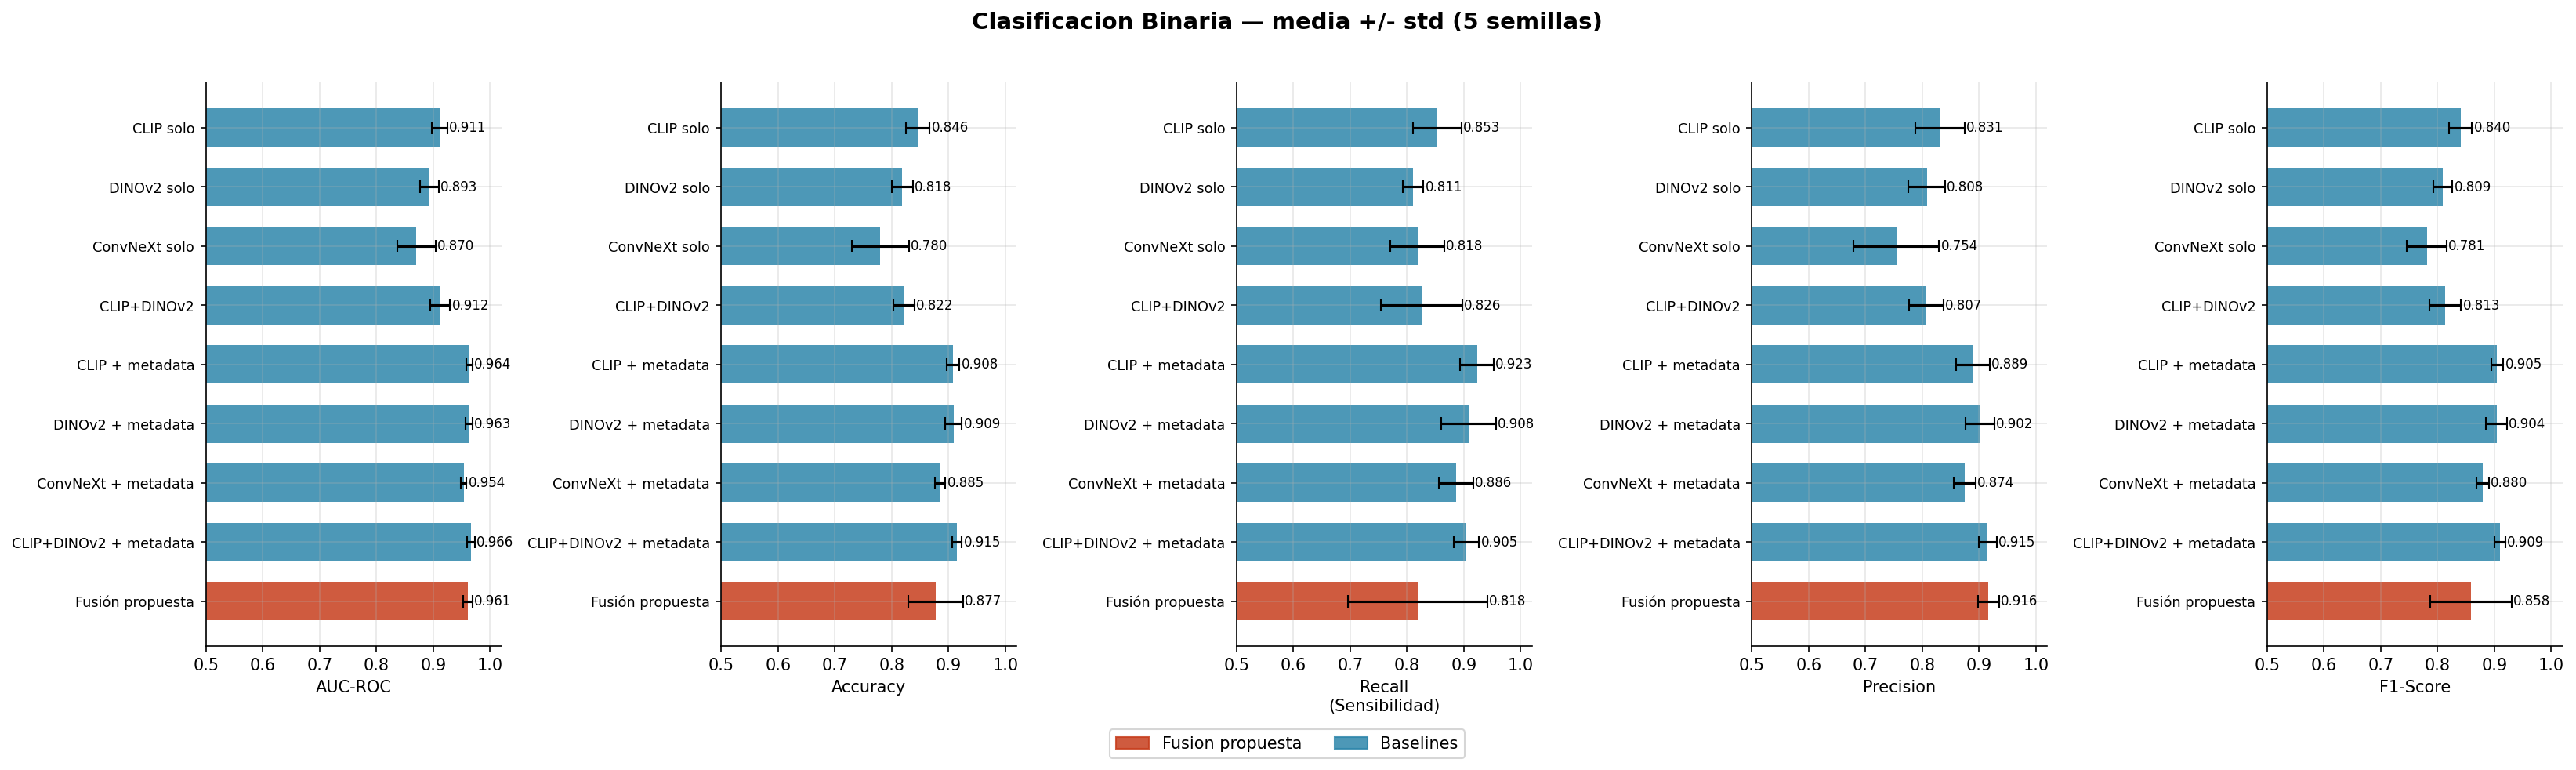

Figura 1 guardada


In [16]:
metricas_bin = ['auc','accuracy','recall','precision','f1']
labels_bin   = ['AUC-ROC','Accuracy','Recall\n(Sensibilidad)','Precision','F1-Score']

df_plot = pd.DataFrame(resultados_bin)
orden = {m:i for i,m in enumerate(MODELOS_ORDER)}
df_plot['ord'] = df_plot['modelo'].map(orden)
df_plot = df_plot.sort_values('ord').reset_index(drop=True)

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Clasificacion Binaria — media +/- std (5 semillas)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, met, lab in zip(axes, metricas_bin, labels_bin):
    medias  = df_plot[met].values
    stds    = df_plot[met+'_std'].values
    modelos = df_plot['modelo'].values
    colors  = ['#C73E1D' if 'propuesta' in m.lower() else '#2E86AB' for m in modelos]
    ax.barh(range(len(modelos)), medias, xerr=stds,
            color=colors, alpha=0.85, capsize=4, height=0.65,
            error_kw={'linewidth':1.5})
    ax.set_yticks(range(len(modelos)))
    ax.set_yticklabels(modelos, fontsize=8.5)
    ax.set_xlabel(lab, fontsize=10)
    ax.set_xlim(0.5, 1.02)
    ax.invert_yaxis()
    for i,(m,s) in enumerate(zip(medias,stds)):
        ax.text(min(m+s+0.003,0.99), i, f'{m:.3f}', va='center', fontsize=8)

prop_p = mpatches.Patch(color='#C73E1D', alpha=0.85, label='Fusion propuesta')
base_p = mpatches.Patch(color='#2E86AB', alpha=0.85, label='Baselines')
fig.legend(handles=[prop_p, base_p], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5,-0.05), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig1_metricas_binario.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 guardada')

## 14. Figura 2 — Boxplots AUC y Recall binario

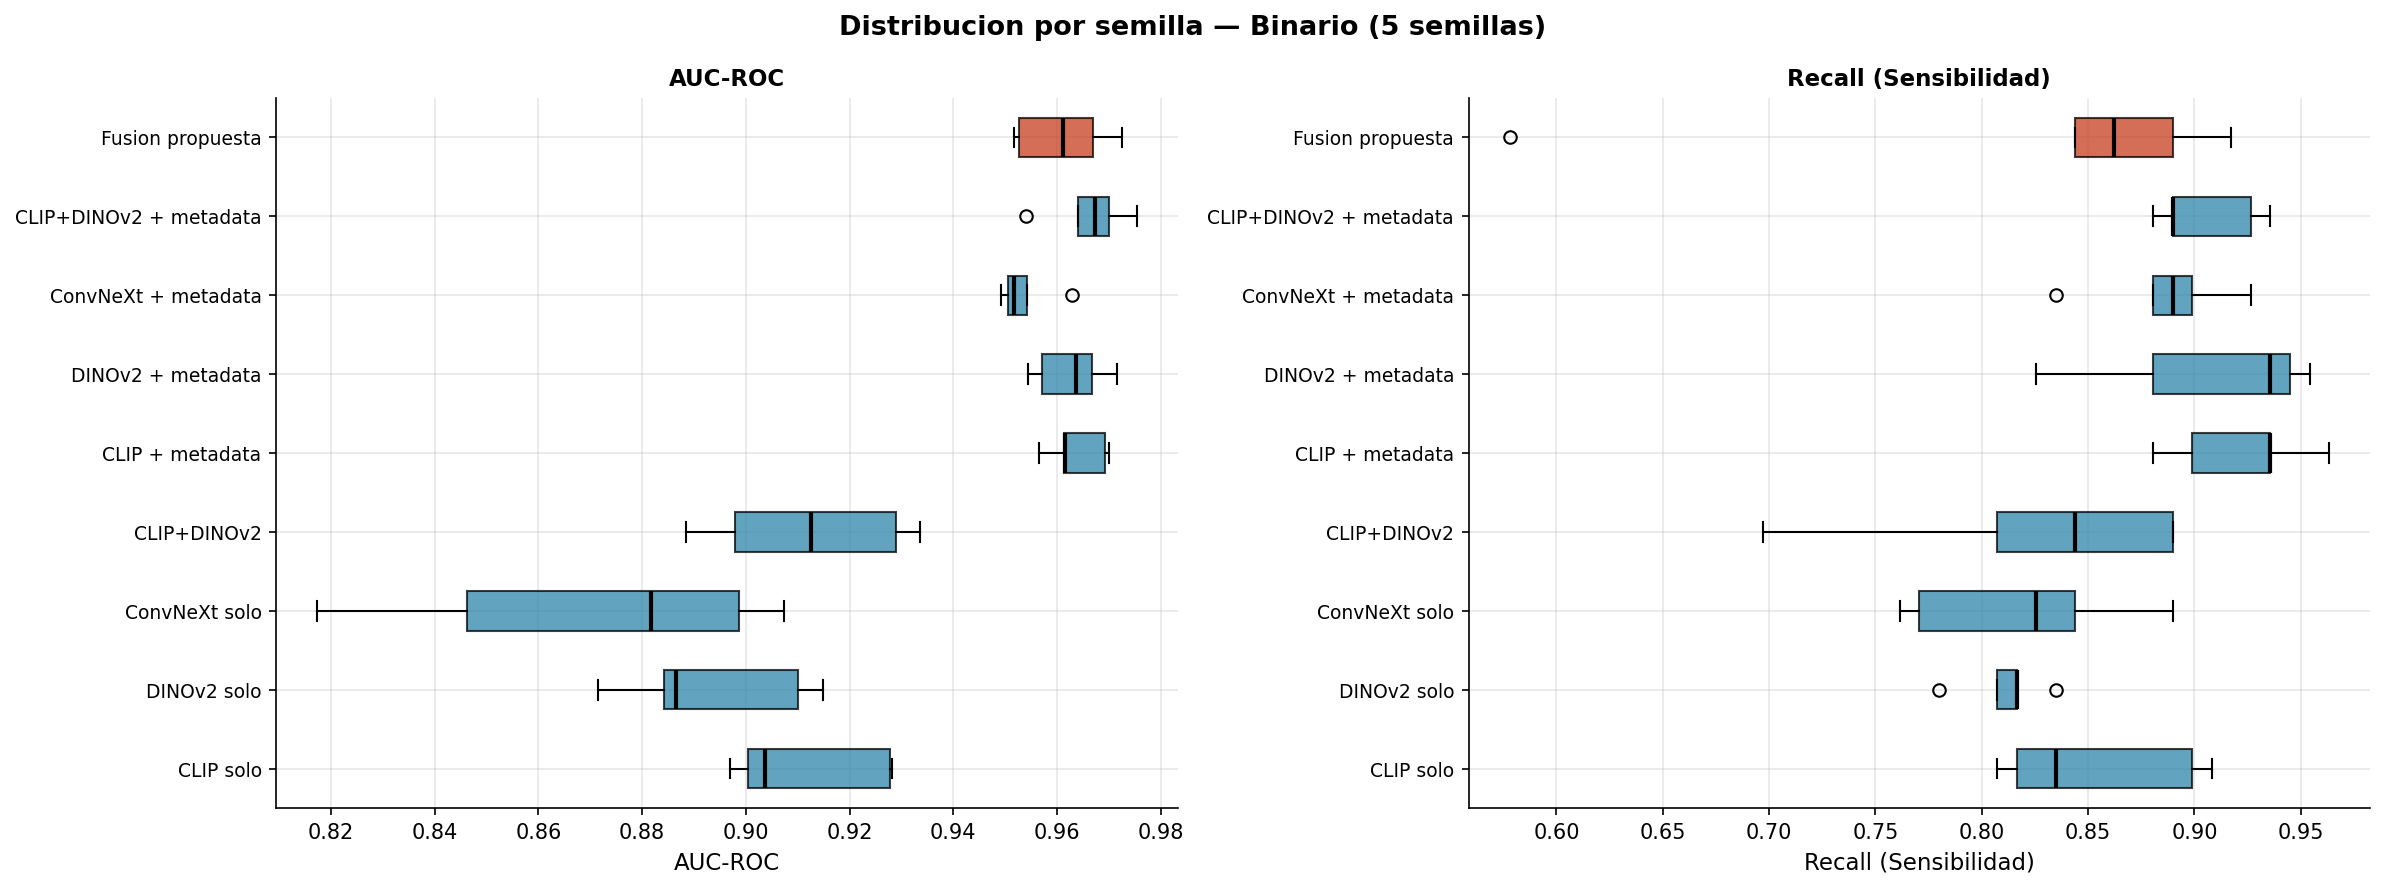

Figura 2 guardada


In [17]:
seed_vals = {m: {'auc':[], 'recall':[]} for m in MODELOS_ORDER}

experimentos_b = [
    ('CLIP solo',             fx_clip,           False),
    ('DINOv2 solo',           fx_dino,           False),
    ('ConvNeXt solo',         fx_conv,           False),
    ('CLIP+DINOv2',           fx_clip_dino,      False),
    ('CLIP + metadata',       fx_clip_meta,      False),
    ('DINOv2 + metadata',     fx_dino_meta,      False),
    ('ConvNeXt + metadata',   fx_conv_meta,      False),
    ('CLIP+DINOv2 + metadata',fx_clip_dino_meta, False),
    ('Fusion propuesta',      fx_fusion,         True),
]

for nombre, fx, is_f in experimentos_b:
    for seed in SEEDS:
        set_seed(seed)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
        tv, te = next(sss.split(np.zeros(len(y_binary)), y_binary))
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.9, random_state=seed)
        tr_r, va_r = next(sss2.split(np.zeros(len(tv)), y_binary[tv]))
        tr_i, va_i = tv[tr_r], tv[va_r]
        X_tr, X_v, X_te = fx(tr_i, va_i, te)
        y_tr2 = y_binary[tr_i]; y_v2 = y_binary[va_i]; y_te2 = y_binary[te]
        crit2 = FocalLossBinary() if is_f else nn.BCEWithLogitsLoss()
        if is_f:
            mdl = FusionModel(meta_dim=meta_dim, n_classes=1)
            met2 = train_fold_fusion(X_tr,y_tr2,X_v,y_v2,X_te,y_te2,mdl,crit2,is_binary=True)
        else:
            mdl = LinearHead(input_dim=X_tr.shape[1], n_classes=1)
            met2 = train_fold(X_tr,y_tr2,X_v,y_v2,X_te,y_te2,mdl,crit2,is_binary=True)
        key = nombre if nombre in seed_vals else 'Fusion propuesta'
        seed_vals[key]['auc'].append(met2['auc'])
        seed_vals[key]['recall'].append(met2['recall'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribucion por semilla — Binario (5 semillas)', fontsize=13, fontweight='bold')
for ax, met, lab in zip(axes, ['auc','recall'], ['AUC-ROC','Recall (Sensibilidad)']):
    data_v = [seed_vals[m][met] for m in MODELOS_ORDER]
    bp = ax.boxplot(data_v, vert=False, patch_artist=True,
                   medianprops={'color':'black','linewidth':2})
    for patch, m in zip(bp['boxes'], MODELOS_ORDER):
        patch.set_facecolor('#C73E1D' if 'propuesta' in m.lower() else '#2E86AB')
        patch.set_alpha(0.75)
    ax.set_yticks(range(1, len(MODELOS_ORDER)+1))
    ax.set_yticklabels(MODELOS_ORDER, fontsize=9)
    ax.set_xlabel(lab, fontsize=11)
    ax.set_title(lab, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig2_boxplot_binario.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 guardada')

## 15. Figura 3 — Metricas multiclase

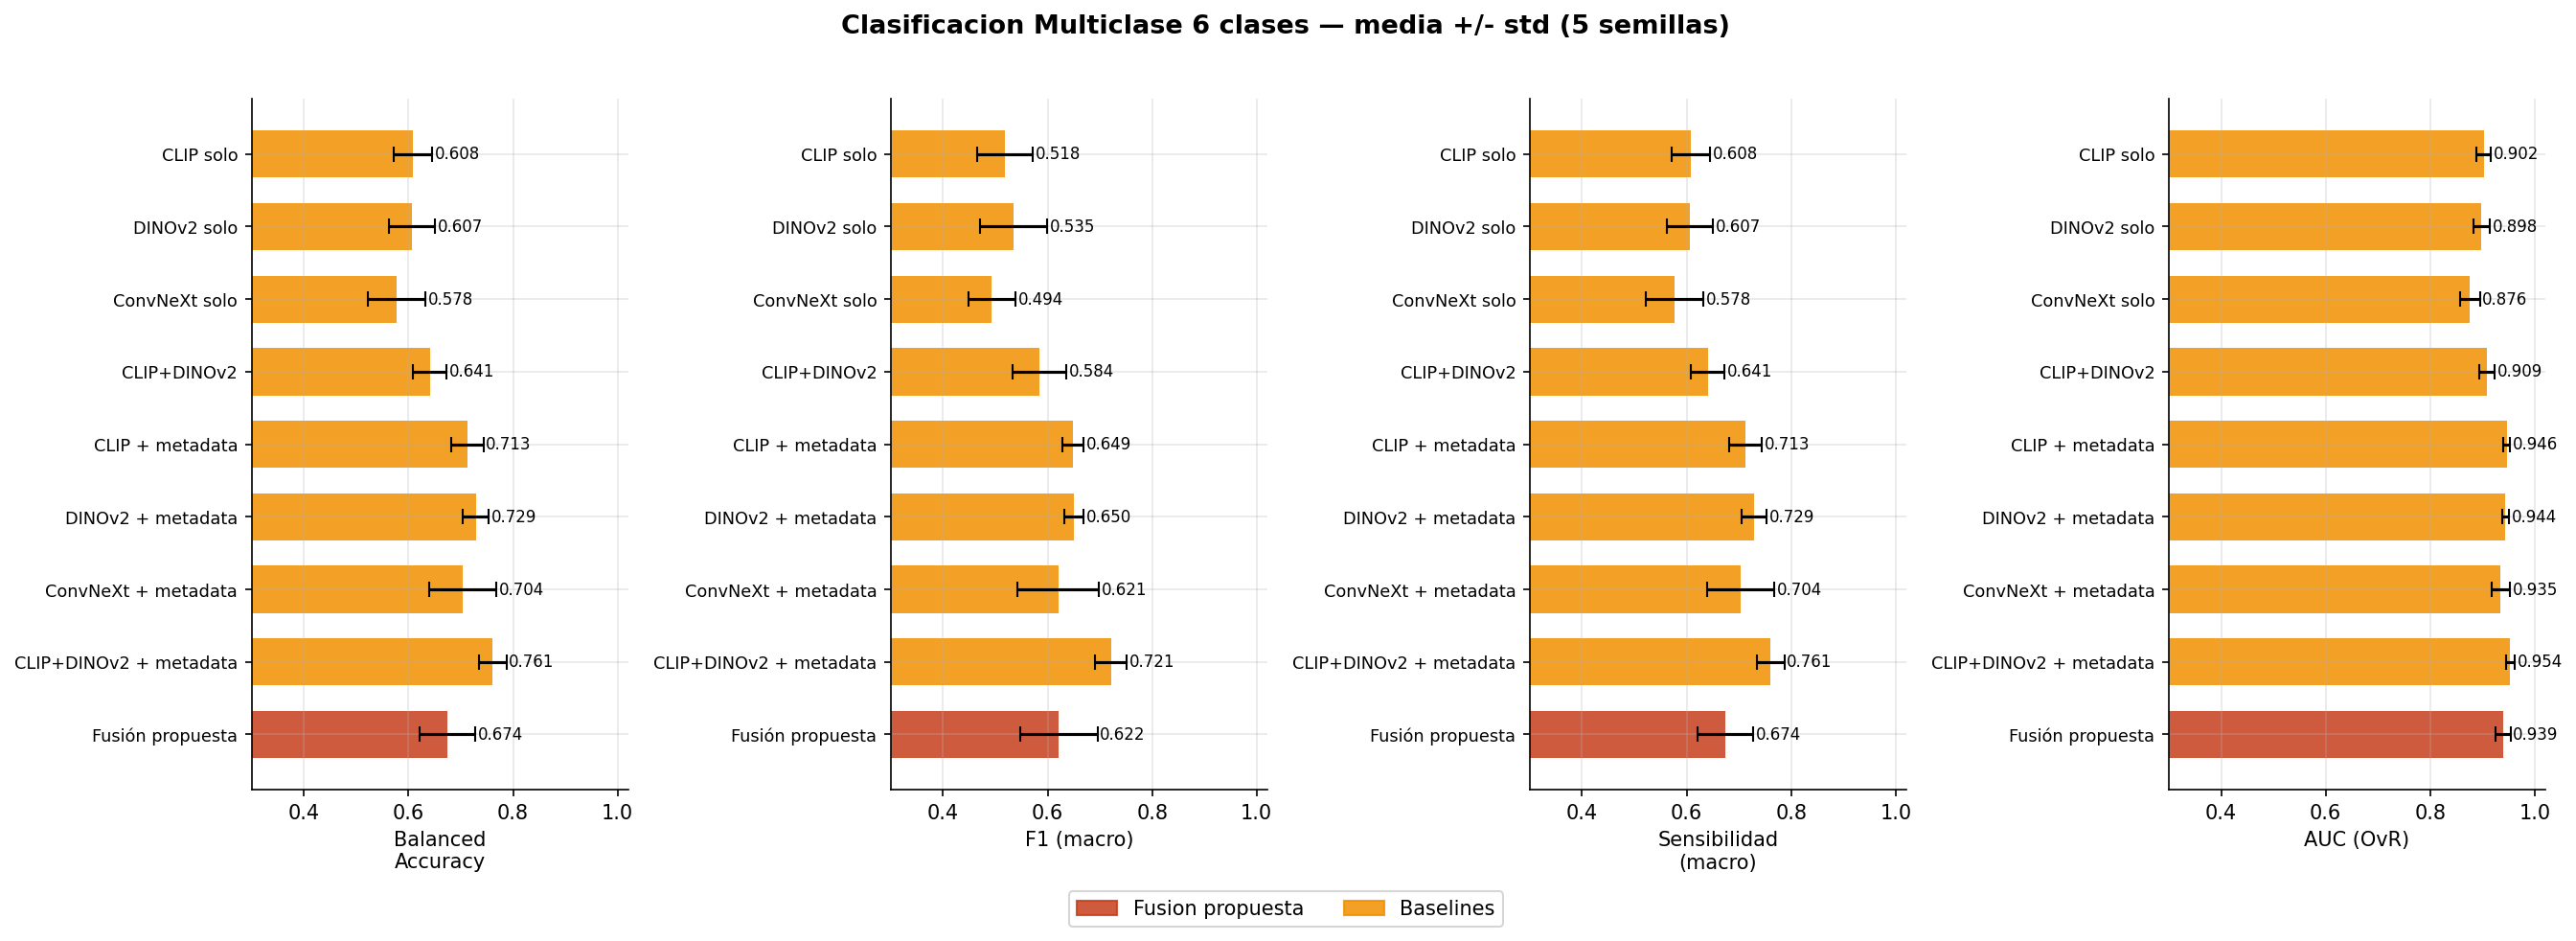

Figura 3 guardada


In [18]:
metricas_m = ['balanced_acc','f1_macro','recall_macro','auc_ovr']
labels_m   = ['Balanced\nAccuracy','F1 (macro)','Sensibilidad\n(macro)','AUC (OvR)']

df_pm = pd.DataFrame(resultados_multi)
df_pm['ord'] = df_pm['modelo'].map({m:i for i,m in enumerate(MODELOS_ORDER)})
df_pm = df_pm.sort_values('ord').reset_index(drop=True)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Clasificacion Multiclase 6 clases — media +/- std (5 semillas)',
             fontsize=13, fontweight='bold', y=1.02)
for ax, met, lab in zip(axes, metricas_m, labels_m):
    medias  = df_pm[met].values
    stds    = df_pm[met+'_std'].values
    modelos = df_pm['modelo'].values
    colors  = ['#C73E1D' if 'propuesta' in m.lower() else '#F18F01' for m in modelos]
    ax.barh(range(len(modelos)), medias, xerr=stds,
            color=colors, alpha=0.85, capsize=4, height=0.65,
            error_kw={'linewidth':1.5})
    ax.set_yticks(range(len(modelos)))
    ax.set_yticklabels(modelos, fontsize=8.5)
    ax.set_xlabel(lab, fontsize=10)
    ax.set_xlim(0.3, 1.02)
    ax.invert_yaxis()
    for i,(m,s) in enumerate(zip(medias,stds)):
        ax.text(min(m+s+0.005,0.99), i, f'{m:.3f}', va='center', fontsize=8)
p1 = mpatches.Patch(color='#C73E1D', alpha=0.85, label='Fusion propuesta')
p2 = mpatches.Patch(color='#F18F01', alpha=0.85, label='Baselines')
fig.legend(handles=[p1,p2], loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.05), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig3_metricas_multiclase.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 guardada')

## 16. Figura 4 — Ablacion por componente (para poster)

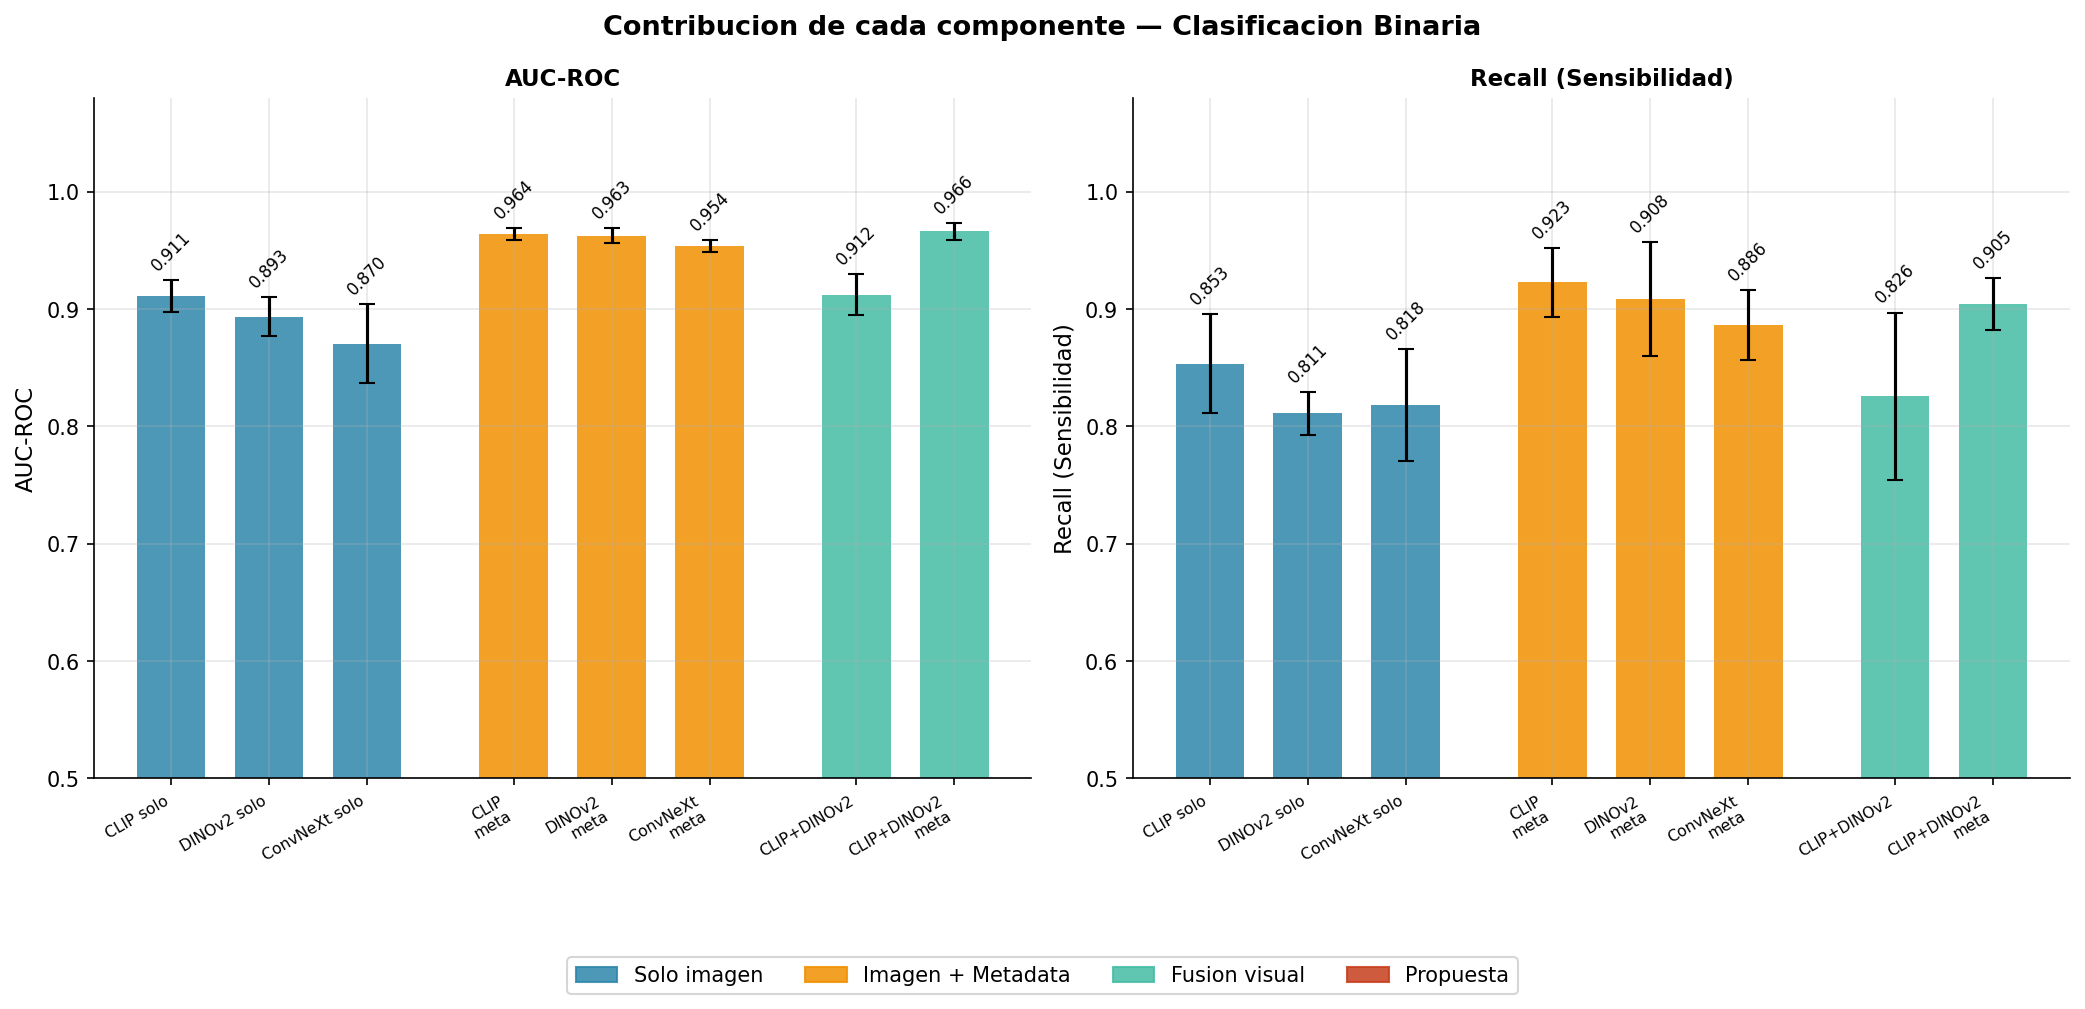

Figura 4 guardada


In [19]:
grupos = {
    'Solo imagen': ['CLIP solo','DINOv2 solo','ConvNeXt solo'],
    'Imagen + Metadata': ['CLIP + metadata','DINOv2 + metadata','ConvNeXt + metadata'],
    'Fusion visual': ['CLIP+DINOv2','CLIP+DINOv2 + metadata'],
    'Propuesta': ['Fusion propuesta']
}
colores_g = {'Solo imagen':'#2E86AB','Imagen + Metadata':'#F18F01',
             'Fusion visual':'#44BBA4','Propuesta':'#C73E1D'}

df_abl = pd.DataFrame(resultados_bin).set_index('modelo')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Contribucion de cada componente — Clasificacion Binaria',
             fontsize=13, fontweight='bold')

for ax, met, lab in zip(axes, ['auc','recall'], ['AUC-ROC','Recall (Sensibilidad)']):
    x_pos = 0
    xticks, xlabels = [], []
    for grupo, mods_g in grupos.items():
        color = colores_g[grupo]
        for m in mods_g:
            nm = 'Fusion propuesta' if m == 'Fusion propuesta' else m
            if nm in df_abl.index:
                val = df_abl.loc[nm, met]
                std = df_abl.loc[nm, met+'_std']
                ax.bar(x_pos, val, yerr=std, color=color, alpha=0.85,
                       capsize=4, width=0.7, error_kw={'linewidth':1.5})
                ax.text(x_pos, val+std+0.005, f'{val:.3f}',
                        ha='center', va='bottom', fontsize=8, rotation=45)
                short = m.replace(' + ','\n').replace('metadata','meta')
                xticks.append(x_pos); xlabels.append(short)
                x_pos += 1
        x_pos += 0.5
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, fontsize=7.5, rotation=30, ha='right')
    ax.set_ylabel(lab, fontsize=11)
    ax.set_ylim(0.5, 1.08)
    ax.set_title(lab, fontsize=11, fontweight='bold')

patches_g = [mpatches.Patch(color=c, label=g, alpha=0.85) for g,c in colores_g.items()]
fig.legend(handles=patches_g, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5,-0.12), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig4_ablacion_componentes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 guardada')

## 17. Figura 5 — Matriz de confusion multiclase (Fusion propuesta)

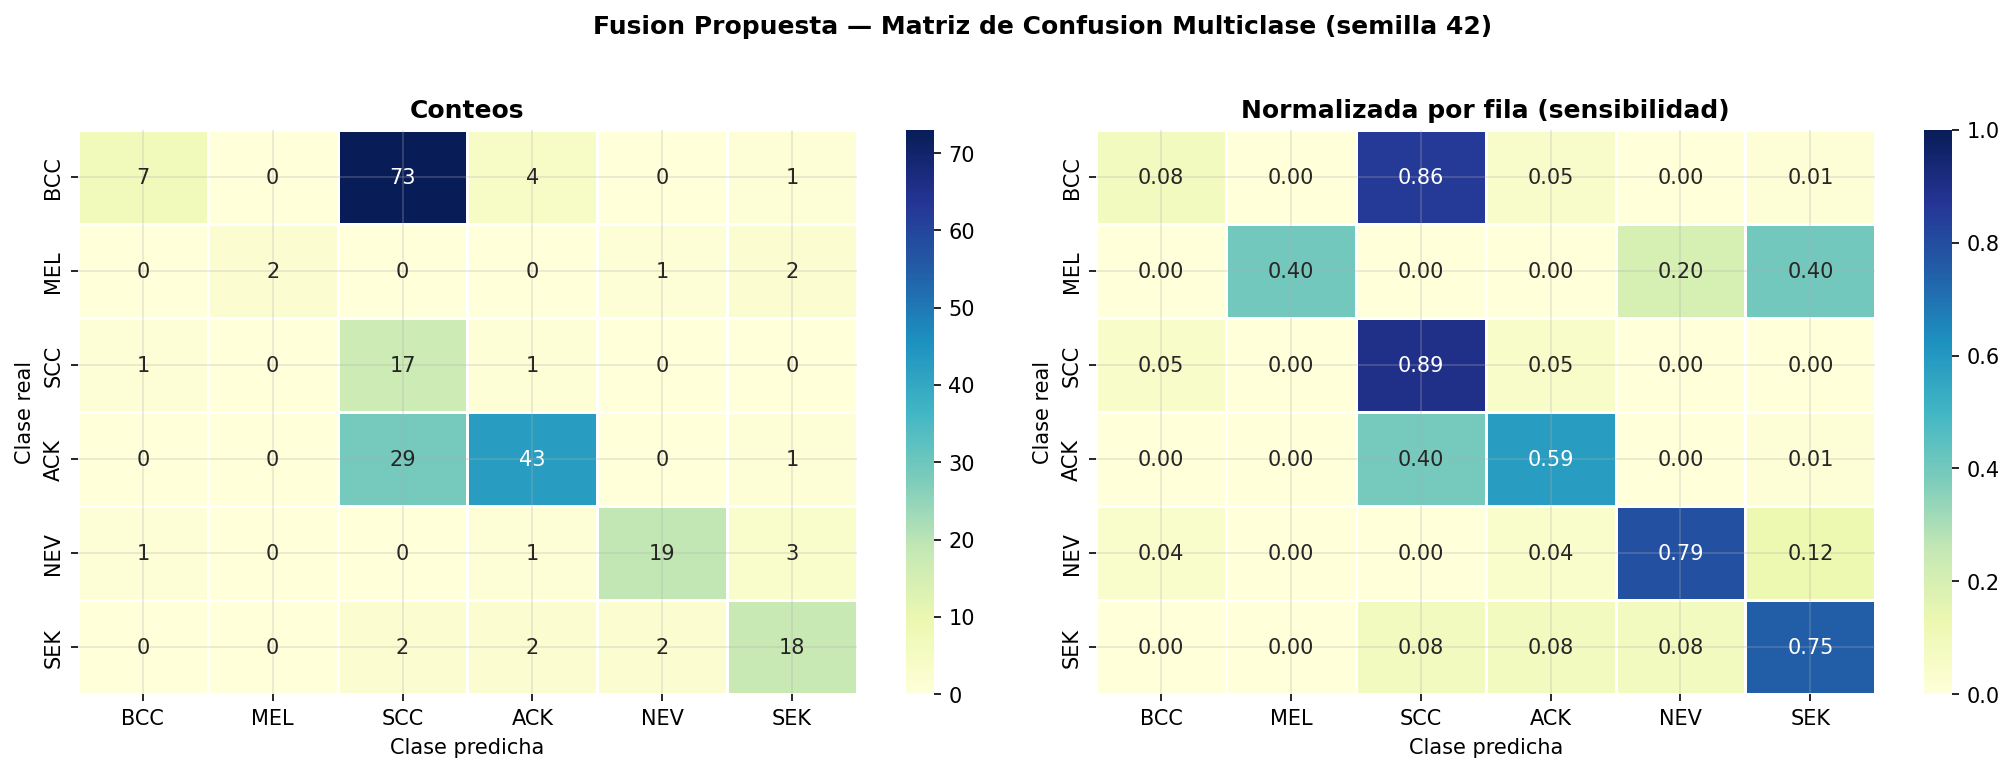

Figura 5 guardada


In [20]:
from sklearn.metrics import confusion_matrix

set_seed(42)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tv_i, te_i = next(sss.split(np.zeros(len(y_multi)), y_multi))
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.9, random_state=42)
tr_r, va_r = next(sss2.split(np.zeros(len(tv_i)), y_multi[tv_i]))
tr_i, va_i = tv_i[tr_r], tv_i[va_r]

X_tr_f, X_v_f, X_te_f = fx_fusion(tr_i, va_i, te_i)
y_tr_f = y_multi[tr_i]; y_v_f = y_multi[va_i]; y_te_f = y_multi[te_i]
cnts = np.bincount(y_tr_f, minlength=6)
wts  = torch.tensor(len(y_tr_f)/(6*cnts), dtype=torch.float32).to(device)
crit_f = FocalLossMulti(alpha=wts, gamma=2.0)
mdl_cm = FusionModel(meta_dim=meta_dim, n_classes=6)
train_fold_fusion(X_tr_f, y_tr_f, X_v_f, y_v_f, X_te_f, y_te_f, mdl_cm, crit_f, is_binary=False)

mdl_cm.eval()
c_te2, d_te2, m_te2 = X_te_f
with torch.no_grad():
    out_cm = mdl_cm(torch.tensor(c_te2).to(device),
                    torch.tensor(d_te2).to(device),
                    torch.tensor(m_te2).to(device))
    preds_cm = out_cm.argmax(1).cpu().numpy()

cm_abs  = confusion_matrix(y_te_f, preds_cm, labels=range(6))
cm_norm = cm_abs.astype(float) / cm_abs.sum(axis=1, keepdims=True)

CLASSES = ['BCC','MEL','SCC','ACK','NEV','SEK']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Conteos', fontweight='bold')
axes[0].set_ylabel('Clase real'); axes[0].set_xlabel('Clase predicha')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Normalizada por fila (sensibilidad)', fontweight='bold')
axes[1].set_ylabel('Clase real'); axes[1].set_xlabel('Clase predicha')

plt.suptitle('Fusion Propuesta — Matriz de Confusion Multiclase (semilla 42)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig5_confusion_propuesta_multi.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 guardada')

## 18. Figura 6 — Heatmap de sensibilidad por clase

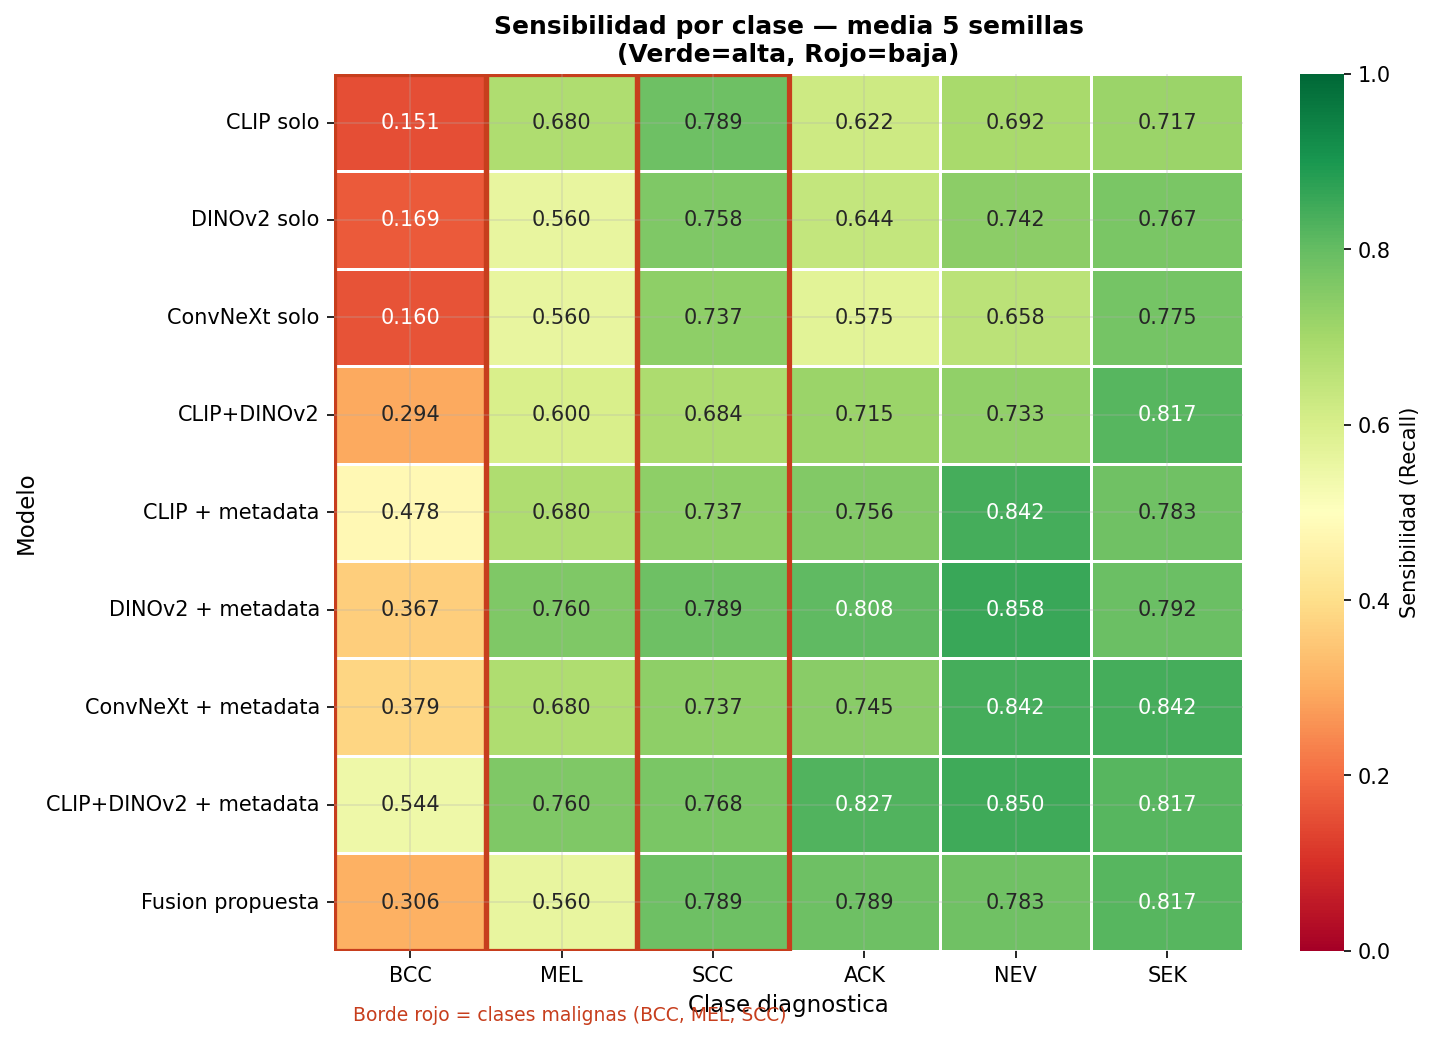

Figura 6 guardada
CSV guardado


In [21]:
from sklearn.metrics import recall_score as rs_fn

sens_d = {m: {c: [] for c in ['BCC','MEL','SCC','ACK','NEV','SEK']} for m in MODELOS_ORDER}

experimentos_m2 = [
    ('CLIP solo',             fx_clip,           False),
    ('DINOv2 solo',           fx_dino,           False),
    ('ConvNeXt solo',         fx_conv,           False),
    ('CLIP+DINOv2',           fx_clip_dino,      False),
    ('CLIP + metadata',       fx_clip_meta,      False),
    ('DINOv2 + metadata',     fx_dino_meta,      False),
    ('ConvNeXt + metadata',   fx_conv_meta,      False),
    ('CLIP+DINOv2 + metadata',fx_clip_dino_meta, False),
    ('Fusion propuesta',      fx_fusion,         True),
]

for nombre, fx, is_f in experimentos_m2:
    for seed in SEEDS:
        set_seed(seed)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
        tv, te = next(sss.split(np.zeros(len(y_multi)), y_multi))
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.9, random_state=seed)
        tr_r, va_r = next(sss2.split(np.zeros(len(tv)), y_multi[tv]))
        tr_i2, va_i2 = tv[tr_r], tv[va_r]
        X_tr3, X_v3, X_te3 = fx(tr_i2, va_i2, te)
        y_tr3 = y_multi[tr_i2]; y_v3 = y_multi[va_i2]; y_te3 = y_multi[te]
        cnts3 = np.bincount(y_tr3, minlength=6)
        wts3  = torch.tensor(len(y_tr3)/(6*cnts3), dtype=torch.float32).to(device)
        crit3 = FocalLossMulti(alpha=wts3, gamma=2.0)
        if is_f:
            mdl3 = FusionModel(meta_dim=meta_dim, n_classes=6)
            train_fold_fusion(X_tr3,y_tr3,X_v3,y_v3,X_te3,y_te3,mdl3,crit3,is_binary=False)
            mdl3.eval()
            c3,d3,m3 = X_te3
            with torch.no_grad():
                preds3 = mdl3(torch.tensor(c3).to(device),
                              torch.tensor(d3).to(device),
                              torch.tensor(m3).to(device)).argmax(1).cpu().numpy()
        else:
            mdl3 = LinearHead(input_dim=X_tr3.shape[1], n_classes=6)
            train_fold(X_tr3,y_tr3,X_v3,y_v3,X_te3,y_te3,mdl3,crit3,is_binary=False)
            mdl3.eval()
            with torch.no_grad():
                preds3 = mdl3(torch.tensor(X_te3, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
        rec_c = rs_fn(y_te3, preds3, average=None, labels=range(6), zero_division=0)
        for i,c in enumerate(['BCC','MEL','SCC','ACK','NEV','SEK']):
            sens_d[nombre][c].append(rec_c[i])

hm_data = pd.DataFrame({
    m: {c: round(float(np.mean(sens_d[m][c])),3) for c in ['BCC','MEL','SCC','ACK','NEV','SEK']}
    for m in MODELOS_ORDER
}).T

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Sensibilidad (Recall)'})
ax.set_title('Sensibilidad por clase — media 5 semillas\n(Verde=alta, Rojo=baja)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Clase diagnostica', fontsize=11)
ax.set_ylabel('Modelo', fontsize=11)
for j, c in enumerate(['BCC','MEL','SCC','ACK','NEV','SEK']):
    if c in ['BCC','MEL','SCC']:
        ax.add_patch(plt.Rectangle((j,0),1,len(MODELOS_ORDER),
                                   fill=False, edgecolor='#C73E1D', lw=2.5))
ax.text(0.02, -0.08, 'Borde rojo = clases malignas (BCC, MEL, SCC)',
        transform=ax.transAxes, fontsize=9, color='#C73E1D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH,'fig6_sensibilidad_por_clase.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 guardada')

hm_data.to_csv(os.path.join(MULTI_PATH,'sensibilidad_por_clase_multisemilla.csv'))
print('CSV guardado')

## 19. Resumen de figuras

In [ ]:
figuras = [
    ('fig1_metricas_binario.png',         'Barras comparativas — 5 metricas binarias (media +/- std)'),
    ('fig2_boxplot_binario.png',          'Boxplots AUC y Recall — distribucion entre semillas'),
    ('fig3_metricas_multiclase.png',      'Barras comparativas — 4 metricas multiclase (media +/- std)'),
    ('fig4_ablacion_componentes.png',     'Ablacion — contribucion de cada componente'),
    ('fig5_confusion_propuesta_multi.png','Matrices de confusion multiclase — Fusion propuesta'),
    ('fig6_sensibilidad_por_clase.png',   'Heatmap sensibilidad por clase — 5 semillas'),
]
print('=== FIGURAS GENERADAS ===')
for fname, desc in figuras:
    exists = 'OK' if os.path.exists(os.path.join(FIG_PATH, fname)) else 'FALTA'
    print(f'  [{exists}] {fname}')
    print(f'       {desc}')
print()
print('Para el POSTER: fig1, fig4, fig5, fig6')
print('Para el ARTICULO: todas')
print('Ruta:', FIG_PATH)